## STAT 306 Project: Vancouver Land Value Associated with Prior Year Values and Age

In [1]:
library(tidyverse)
library(dplyr)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some


Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2



--------------------------
#### Data cleaning

In [4]:
property <- read.csv(
  file = "./data/sample_data.csv"
) |>
  subset(select = c(CURRENT_LAND_VALUE,
    PREVIOUS_LAND_VALUE,
    PREVIOUS_IMPROVEMENT_VALUE,
    YEAR_BUILT, ZONING_CLASSIFICATION,
    LEGAL_TYPE
  )) |>
  na.omit()

property2 <- subset(property,
  is.finite(CURRENT_LAND_VALUE) & CURRENT_LAND_VALUE > 0 &
  is.finite(PREVIOUS_LAND_VALUE) & PREVIOUS_LAND_VALUE > 0 &
  is.finite(PREVIOUS_IMPROVEMENT_VALUE) & PREVIOUS_IMPROVEMENT_VALUE > 0 &
  is.finite(YEAR_BUILT)
)


nrow(property) - nrow(property2) ## we check how many rows were dropped
sample_n(property, 10) ## looking at our data


[1] 4

CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION,LEGAL_TYPE
<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
1175840,1099408,109000,1995,Industrial,STRATA
490000,508000,230000,1996,Industrial,STRATA
1301000,1201000,24800,1912,Two-Family Dwelling,LAND
3654000,3616000,56100,1950,Residential,LAND
162000,207000,106000,1994,Comprehensive Development,STRATA
186000,170000,55100,1997,Comprehensive Development,STRATA
386000,403000,128000,2006,Comprehensive Development,STRATA
1502000,1416000,36400,1929,One-Family Dwelling,LAND
1192000,1069000,157000,1929,One-Family Dwelling,LAND


In [5]:
# See how many variables in ZONING CLASSIFICATION

unique(property$ZONING_CLASSIFICATION)
length(unique(property$ZONING_CLASSIFICATION))

[1] "Residential Inclusive"     "One-Family Dwelling"      
 [3] "Comprehensive Development" "Industrial"               
 [5] "Commercial"                "Multiple Dwelling"        
 [7] "Residential"               "Two-Family Dwelling"      
 [9] "Historical Area"           "Other"                    
[11] ""                          "Limited Agriculture"

[1] 12

In [6]:
# See what missing values in ZONING CLASSIFICATION

property[property$ZONING_CLASSIFICATION == '',]

,CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION,LEGAL_TYPE
,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
175,537000,609000,145000,2017,,STRATA
605,320000,310000,166000,2018,,STRATA
991,1523000,1811000,126000,1983,,LAND
1511,494000,551000,298000,2018,,STRATA
1676,520000,503000,281000,2018,,STRATA
1890,300000,350000,187000,2018,,STRATA
1946,420000,491000,261000,2018,,STRATA
1985,732000,822000,349000,2017,,STRATA


In [7]:
# Simplify ZONING CLASSIFICATION into 5 categories: Residential, Commercial, Industrial, Agriculture, Special

property2$ZONE_SIMPLE <- dplyr::case_when(
  property2$ZONING_CLASSIFICATION %in% c(
    "Residential Inclusive",
    "One-Family Dwelling",
    "Two-Family Dwelling",
    "Multiple Dwelling",
    "Residential"
  ) ~ "Residential",

  property2$ZONING_CLASSIFICATION == "Commercial" ~ "Commercial",

  property2$ZONING_CLASSIFICATION == "Industrial" ~ "Industrial",

  property2$ZONING_CLASSIFICATION == "Limited Agriculture" ~ "Agriculture",
  property2$ZONING_CLASSIFICATION %in% c(
    "Comprehensive Development",
    "Historical Area",
    "",
    "Other"
  ) ~ "Special"
)

In [8]:
unique(property$ZONE_SIMPLE)
length(unique(property$ZONE_SIMPLE))

NULL

[1] 0

In [9]:
colSums(is.na(property))

CURRENT_LAND_VALUE        PREVIOUS_LAND_VALUE 
                         0                          0 
PREVIOUS_IMPROVEMENT_VALUE                 YEAR_BUILT 
                         0                          0 
     ZONING_CLASSIFICATION                 LEGAL_TYPE 
                         0                          0

--------------------------
#### Fitting Models

In [24]:
fit <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, data = property2)
bb <- coef(fit)
# bb
fit_both <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE + LEGAL_TYPE, data = property2)
fit_legal <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE, data = property2)
cat("Additive Model with ZONE_SIMPLE")
summary(fit)
cat(" \n \n Additive Model with LEGAL_TYPE")
summary(fit_legal)
cat("\n \n Additive Model with both ZONE_SIMPLE and LEGAL_TYPE")
summary(fit_both)

Additive Model with ZONE_SIMPLE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59795 -0.05408  0.00553  0.05932  0.62958 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0132292  0.2159266   4.692 2.89e-06 ***
log(PREVIOUS_LAND_VALUE)         0.9778953  0.0030995 315.506  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0072486  0.0024881   2.913  0.00362 ** 
YEAR_BUILT                      -0.0003358  0.0001042  -3.222  0.00130 ** 
ZONE_SIMPLECommercial           -0.1275848  0.0998699  -1.278  0.20158    
ZONE_SIMPLEIndustrial           -0.1172861  0.1006505  -1.165  0.24405    
ZONE_SIMPLEResidential          -0.1051328  0.0993653  -1.058  0.29017    
ZONE_SIMPLESpecial              -0.1439204  0.0996020  -1.445  0.14864    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

 
 
 Additive Model with LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61971 -0.05159  0.00621  0.05958  0.62759 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0848516  0.2050339   5.291 1.36e-07 ***
log(PREVIOUS_LAND_VALUE)         0.9765394  0.0034544 282.696  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0067324  0.0024847   2.710  0.00680 ** 
YEAR_BUILT                      -0.0004126  0.0001026  -4.024 5.96e-05 ***
LEGAL_TYPEOTHER                 -0.3114227  0.0976756  -3.188  0.00145 ** 
LEGAL_TYPESTRATA                -0.0272562  0.0067686  -4.027 5.88e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.09753 on 1893 degrees of freedom
Multiple R-squared:  0.9903,	Adjusted R-squared:  0.9903 
F-statisti


 
 Additive Model with both ZONE_SIMPLE and LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE + 
    LEGAL_TYPE, data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.60188 -0.05217  0.00681  0.05851  0.62615 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      0.9967263  0.2161040   4.612 4.25e-06 ***
log(PREVIOUS_LAND_VALUE)         0.9759416  0.0034986 278.951  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0078445  0.0025120   3.123  0.00182 ** 
YEAR_BUILT                      -0.0003128  0.0001061  -2.948  0.00324 ** 
ZONE_SIMPLECommercial           -0.1292058  0.0996741  -1.296  0.19504    
ZONE_SIMPLEIndustrial           -0.1194221  0.1004580  -1.189  0.23468    
ZONE_SIMPLEResidential          -0.1107163  0.0992515  -1.116  0.26477    
ZONE_SIMPLESpecial              -0.1450364  0.0994055  -1.459  0.14472    
LEGAL_TYPEOTHER                 

In [25]:
cat("VIF of model with ZONE_SIMPLE")
vif(fit)
cat("\n \n VIF of model with LEGAL_TYPE")
vif(fit_legal)
cat("\n \n VIF of model with both ZONE_SIMPLE and LEGAL_TYPE")
vif(fit_both)

VIF of model with ZONE_SIMPLE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),1.910710,1,1.382284
log(PREVIOUS_IMPROVEMENT_VALUE),1.741281,1,1.319576
YEAR_BUILT,1.951691,1,1.397029
ZONE_SIMPLE,1.676039,4,1.066683



 
 VIF of model with LEGAL_TYPE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),2.352312,1,1.533725
log(PREVIOUS_IMPROVEMENT_VALUE),1.721112,1,1.311911
YEAR_BUILT,1.872904,1,1.368541
LEGAL_TYPE,2.191729,2,1.216737



 
 VIF of model with both ZONE_SIMPLE and LEGAL_TYPE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),2.444450,1,1.563474
log(PREVIOUS_IMPROVEMENT_VALUE),1.782100,1,1.334953
YEAR_BUILT,2.030742,1,1.425041
ZONE_SIMPLE,2.204034,4,1.103830
LEGAL_TYPE,2.882178,2,1.302957


In [10]:
fit_int <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * ZONE_SIMPLE + 
              log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)
anova(fit, fit_int)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1891,17.82879,NA,NA,NA,NA
2,1888,17.75880,3,0.06999295,2.480399,0.05942339


--------------------------
#### Plots

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


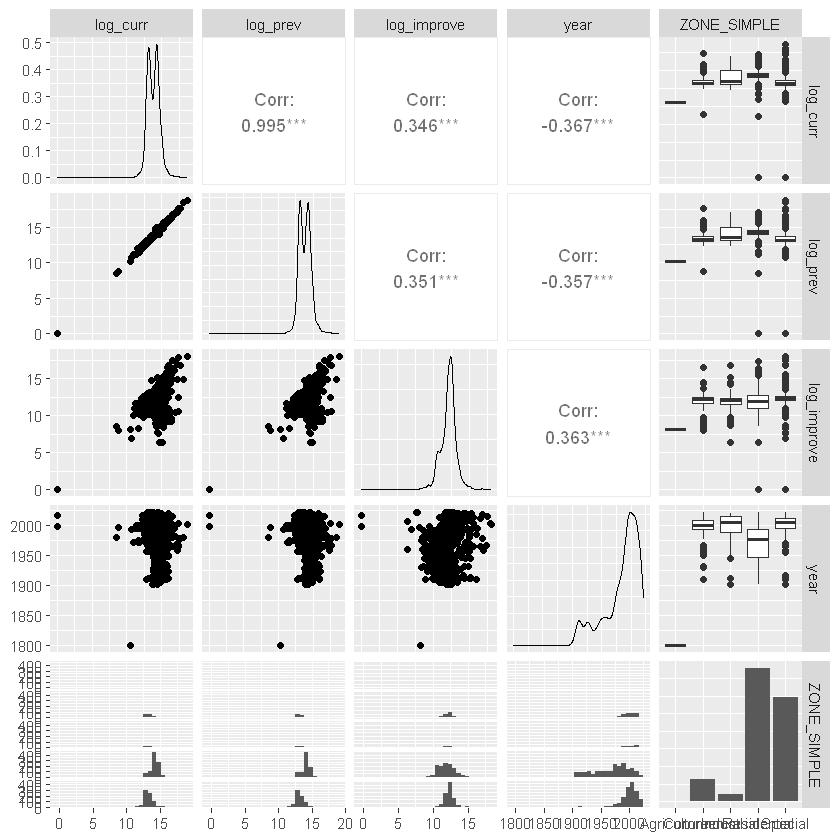

In [11]:
property_log <- property2 |>
                mutate(log_curr = log(CURRENT_LAND_VALUE),
                log_prev = log(PREVIOUS_LAND_VALUE),
                log_improve = log(PREVIOUS_IMPROVEMENT_VALUE),
                year = as.numeric(YEAR_BUILT)) |>
                select(log_curr, log_prev, log_improve, year, ZONE_SIMPLE)
ggpairs(property_log)

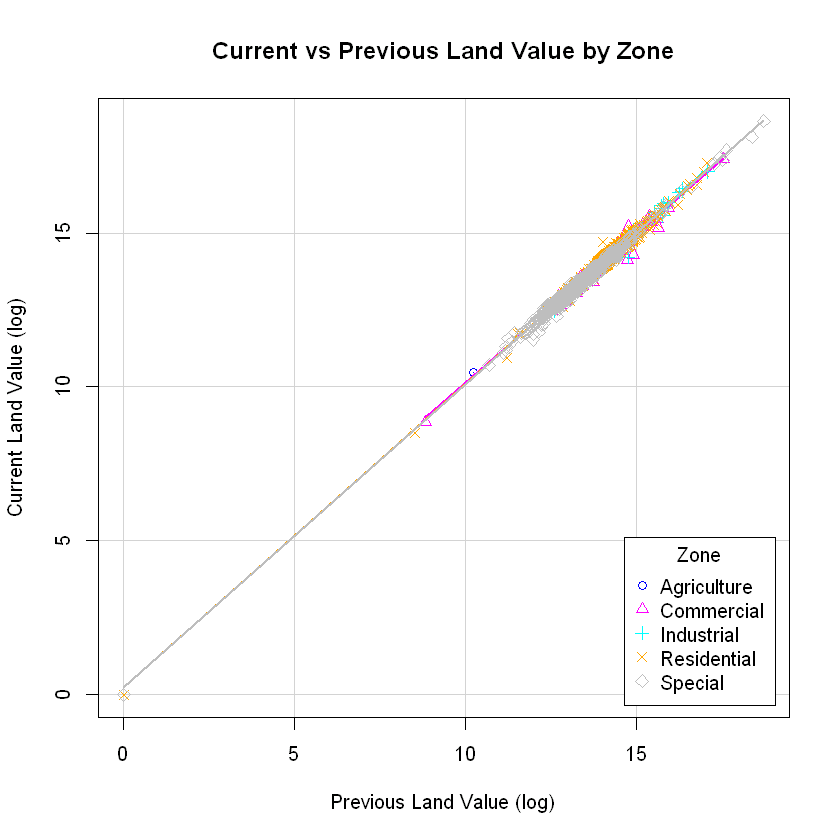

In [12]:
scatterplot(
    log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)|ZONE_SIMPLE, 
    smooth=FALSE, 
    by.groups=TRUE,
    xlab = "Previous Land Value (log)", 
    ylab = "Current Land Value (log)",
    main = "Current vs Previous Land Value by Zone",
    legend = list(title = "Zone", coords = "bottomright"),
    data = property2
    )

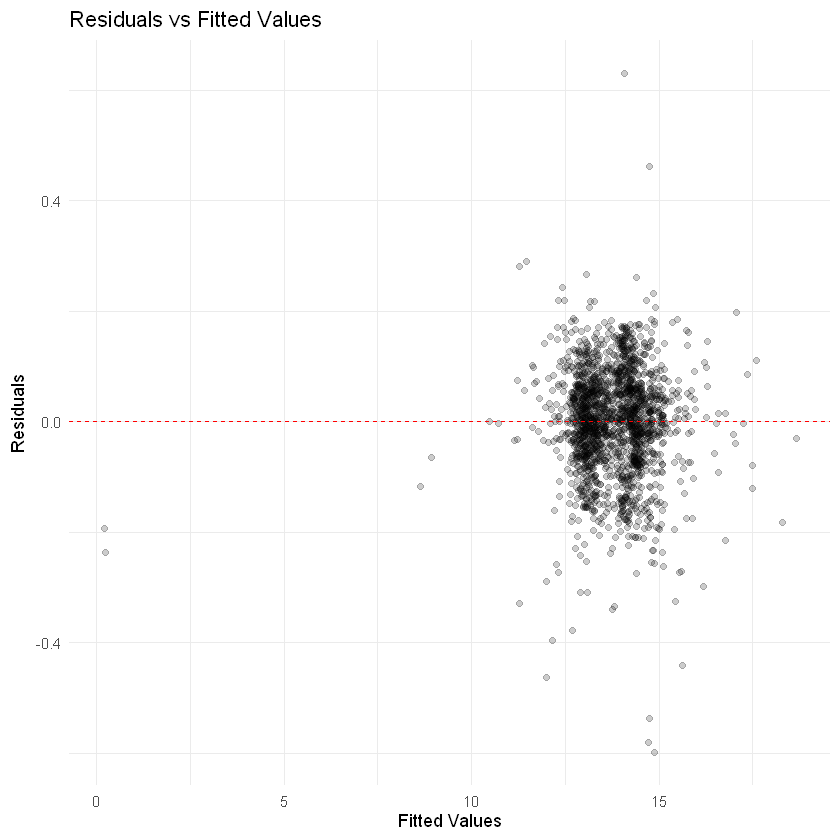

In [13]:
#ggplot2 for the red line
ggplot(data.frame(fitted = fit$fitted.values, residuals = fit$residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.2) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Fitted Values", 
       y = "Residuals",
       title = "Residuals vs Fitted Values") +
  theme_minimal()

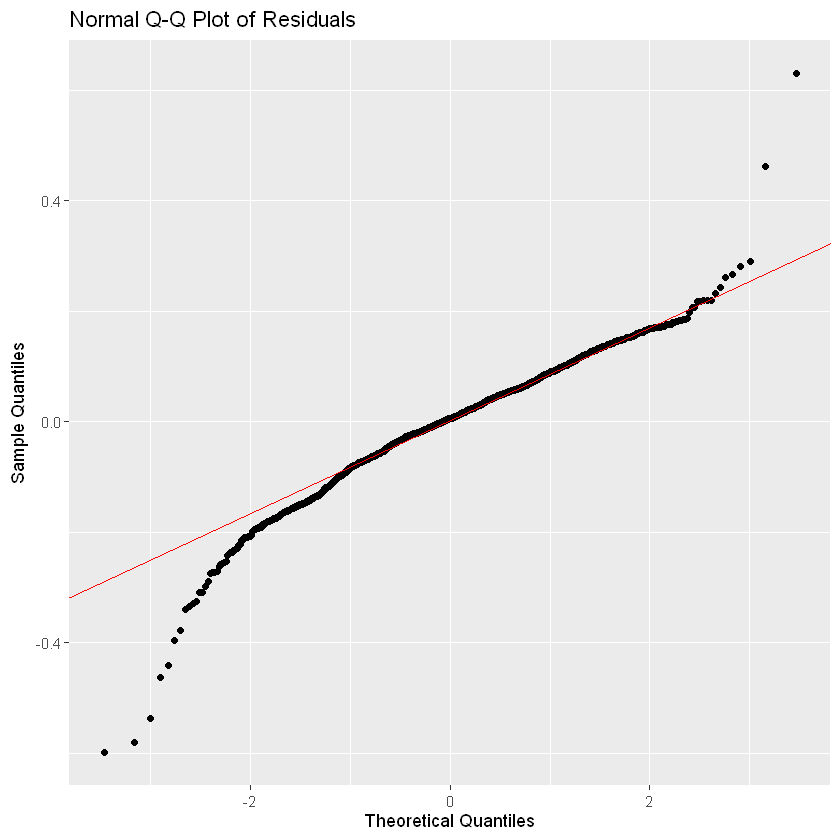

In [14]:
# ggplot2
ggplot(data.frame(resid = residuals(fit)), aes(sample = resid)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(
    title = "Normal Q-Q Plot of Residuals",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )